# News Category Classification
Classify AG News articles into **World, Sports, Business, and Sci/Tech** using TF-IDF and Logistic Regression.

## 1. Setup

In [1]:
from collections import Counter
from functools import lru_cache
from pathlib import Path
import html
import re

import matplotlib.pyplot as plt
import nltk
import pandas as pd
from IPython.display import display
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
)
from sklearn.pipeline import Pipeline

for corpus_name in ("stopwords", "wordnet"):
    try:
        getattr(nltk.corpus, corpus_name).ensure_loaded()
    except LookupError:
        nltk.download(corpus_name, quiet=True, raise_on_error=True)
plt.rcParams.update({"figure.figsize": (8, 4)})

## 2. Load and Explore the Data

In [3]:
DATA_DIR = next(
    (path for path in [Path("archive")]
     if (path / "train.csv").is_file() and (path / "test.csv").is_file()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("Run this notebook from Task_2 or the project root.")

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
category_names = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

print(f"Training articles: {len(train_df):,}")
print(f"Test articles: {len(test_df):,}")
display(train_df.head())
display(pd.DataFrame({
    "Train missing": train_df.isna().sum(),
    "Test missing": test_df.isna().sum(),
}))

Training articles: 120,000
Test articles: 7,600


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


,Train missing,Test missing
Class Index,0,0
Title,0,0
Description,0,0


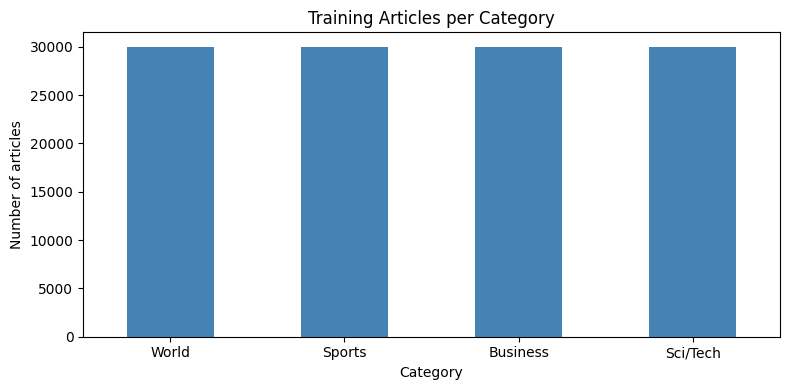

In [3]:
for frame in (train_df, test_df):
    frame["category"] = frame["Class Index"].map(category_names)
    frame["text"] = (
        frame["Title"].fillna("") + " " + frame["Description"].fillna("")
    ).str.strip()

train_df["category"].value_counts().reindex(category_names.values()).plot(
    kind="bar", color="steelblue", rot=0
)
plt.title("Training Articles per Category")
plt.xlabel("Category")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

## 3. Preprocess the Text
Combine titles and descriptions, lowercase, tokenize, remove stopwords, and lemmatize.

In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

@lru_cache(maxsize=100_000)
def lemmatize_token(token):
    return lemmatizer.lemmatize(lemmatizer.lemmatize(token, pos="v"), pos="n")

def preprocess_text(text):
    text = html.unescape(str(text)).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    tokens = re.findall(r"[a-z]+", text)
    lemmas = [
        lemmatize_token(token)
        for token in tokens
        if len(token) > 2 and token not in stop_words
    ]
    return " ".join(word for word in lemmas if word not in stop_words)

for frame in (train_df, test_df):
    frame["clean_text"] = frame["text"].map(preprocess_text)

display(train_df[["text", "clean_text"]].head(3))

,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall bear claw back black reuters reuters shor...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle look toward commercial aerospace reute...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stock outlook reuters reuter...


In [5]:
# Remove empty texts and repeated training articles.
train_df = train_df.loc[train_df["clean_text"].ne("")].copy()
test_df = test_df.loc[test_df["clean_text"].ne("")].copy()
train_df = train_df.drop_duplicates(subset="clean_text").copy()

# Keep the provided test split held out; remove matching texts from training.
overlap = train_df["clean_text"].isin(test_df["clean_text"])
print(f"Train/test text overlaps removed from training: {overlap.sum():,}")
train_df = train_df.loc[~overlap].copy()
print(f"Final split: {len(train_df):,} train / {len(test_df):,} test")

Train/test text overlaps removed from training: 108
Final split: 118,925 train / 7,600 test


## 4. TF-IDF and Model Training
Fit unigram/bigram TF-IDF features and a multiclass classifier using only the training split.

In [6]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

model.fit(train_df["clean_text"], train_df["Class Index"])
print(f"TF-IDF features: {len(model.named_steps['tfidf'].vocabulary_):,}")

TF-IDF features: 50,000


## 5. Evaluate the Classifier

In [7]:
y_test = test_df["Class Index"]
y_pred = model.predict(test_df["clean_text"])

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(classification_report(
    y_test, y_pred,
    labels=list(category_names),
    target_names=list(category_names.values()),
    digits=3,
    zero_division=0,
))

Accuracy: 91.53%
Macro F1: 0.9151
              precision    recall  f1-score   support

       World      0.931     0.907     0.919      1900
      Sports      0.954     0.977     0.965      1900
    Business      0.884     0.879     0.882      1900
    Sci/Tech      0.891     0.897     0.894      1900

    accuracy                          0.915      7600
   macro avg      0.915     0.915     0.915      7600
weighted avg      0.915     0.915     0.915      7600



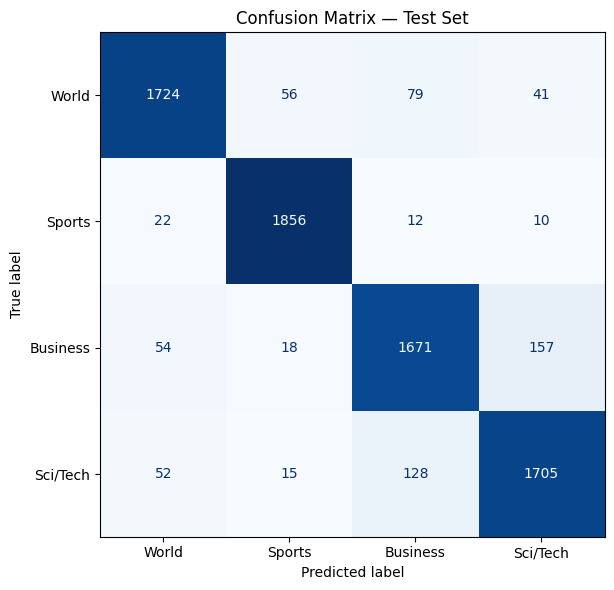

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=list(category_names),
    display_labels=list(category_names.values()),
    cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

## 6. Bonus: Most Frequent Words per Category

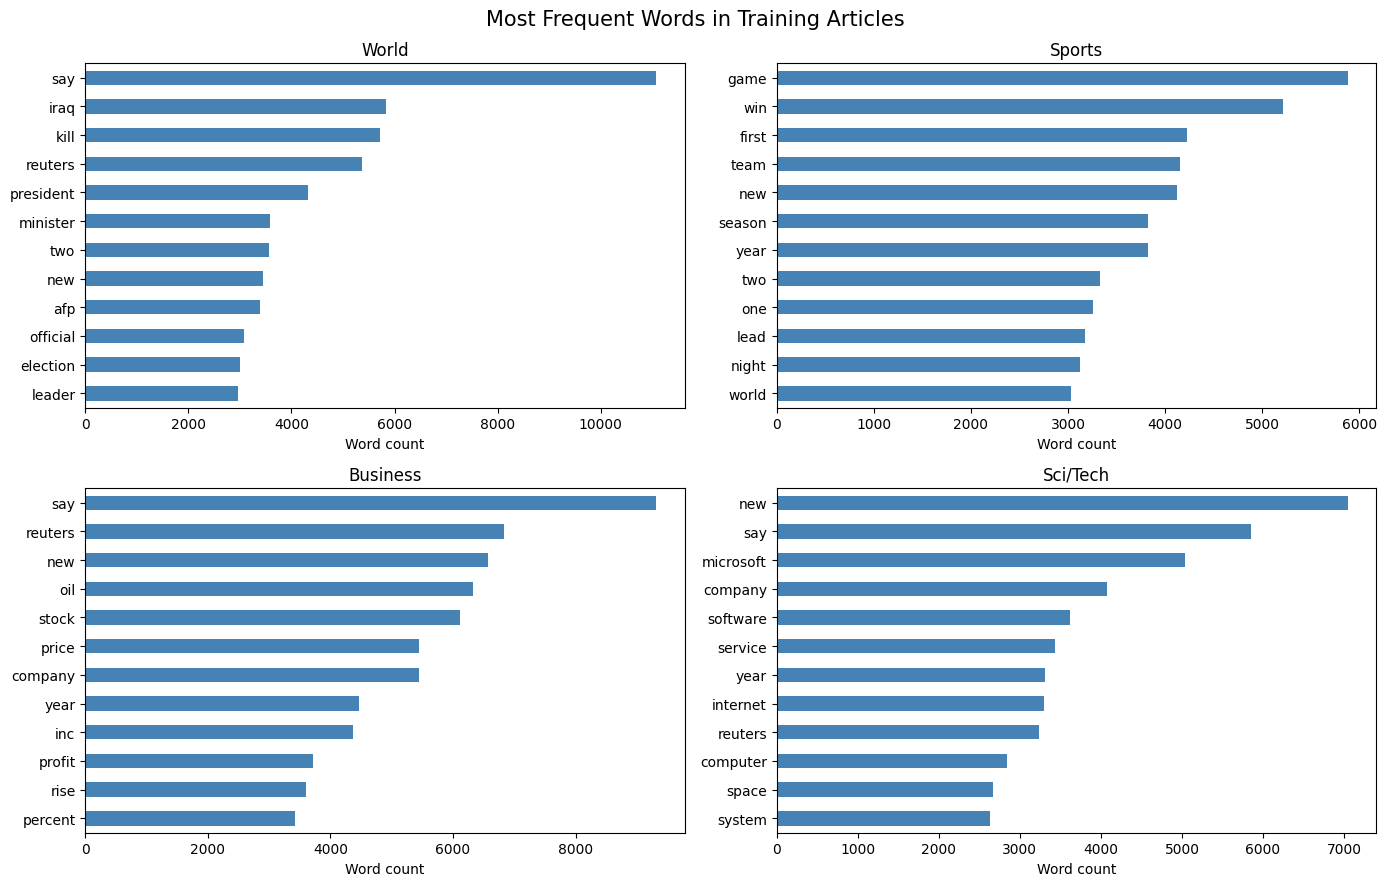

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (label, category) in zip(axes.flat, category_names.items()):
    counts = Counter()
    for text in train_df.loc[train_df["Class Index"].eq(label), "clean_text"]:
        counts.update(text.split())
    top_words = pd.Series(dict(counts.most_common(12))).sort_values()
    top_words.plot.barh(ax=ax, color="steelblue")
    ax.set_title(category)
    ax.set_xlabel("Word count")

fig.suptitle("Most Frequent Words in Training Articles", fontsize=15)
plt.tight_layout()
plt.show()

## 7. Predict New Articles

In [10]:
new_articles = [
    "The national team won the football championship after a dramatic final.",
    "Stocks rose as the company reported higher quarterly profits.",
    "Researchers unveiled a new computer chip for artificial intelligence.",
    "World leaders met to discuss peace talks and international relations.",
]
predictions = model.predict([preprocess_text(text) for text in new_articles])
display(pd.DataFrame({
    "Article": new_articles,
    "Predicted category": [category_names[label] for label in predictions],
}))

,Article,Predicted category
0,The national team won the football championshi...,Sports
1,Stocks rose as the company reported higher qua...,Business
2,Researchers unveiled a new computer chip for a...,Sci/Tech
3,World leaders met to discuss peace talks and i...,World
